# Diagnostic de Defauts Moteur par Apprentissage Automatique
# Classification a partir de Signaux de Courant Triphase (Dataset ITSC)

---

**Objectif** : Entrainer des modeles de classification a 3 classes pour la detection
de defauts dans un moteur a induction, a partir de signaux de courant triphase.

**Classes** :
- **Normal** : fonctionnement sain
- **Surcharge** : defauts inter-spires legers (10-20%)
- **Court-circuit** : defauts inter-spires severes (30-40%)

**Contrainte** : modeles legers compatibles avec un deploiement sur microcontroleur ESP32.

**Dataset** : ITSC Dataset — signaux de courant triphase d'un moteur a induction
instrumente avec des defauts de court-circuit inter-spires.
Cardenas-Cornejo et al., Measurement, 2023.

---

## Table des matieres

1. Installation des dependances
2. Presentation du dataset
3. Chargement des donnees
4. Analyse exploratoire
5. Extraction des caracteristiques
6. Preparation des donnees
7. Entrainement des modeles
8. Evaluation comparative
9. Importance des caracteristiques
10. Exportation pour ESP32

---
## 1. Installation des dependances

In [1]:
# Decommentez la ligne ci-dessous pour installer les dependances dans Google Colab :
!pip install xgboost m2cgen scikit-learn pandas numpy matplotlib seaborn scipy -q

---
## 2. Presentation du dataset ITSC

Le dataset ITSC (Inter-Turn Short-Circuit) a ete acquis au Laboratoire de Genie
Electrique de l'Universite de Guanajuato, Mexique. Il contient des mesures de
courant triphase (phases A, B, C) realisees sur un moteur a induction a cage
d'ecureuil Baldor CM3542 (0.75 HP, 230 VAC, 1725 RPM, 60 Hz).

### Protocole d'acquisition
- Capteurs : transformateurs de courant SCT013
- Module : NI-9215
- Echantillonnage : 1 kHz, 5 secondes par acquisition
- Conditions : regime permanent, sans charge
- 5 repetitions par condition experimentale

### Version utilisee : Cropped_Signals_SF
Les signaux ont ete filtres et recadres sur l'etat stationnaire du defaut.
Chaque fichier CSV contient **1000 echantillons x 3 phases** (1 seconde de signal).

### Classes originales (13)
Le dataset original comporte 13 classes :
- `SC_HLT` : etat sain
- `SC_AX_B0_C0` : defaut phase A au niveau X (X = 1 a 4, soit 10% a 40%)
- `SC_A0_BX_C0` : defaut phase B au niveau X
- `SC_A0_B0_CX` : defaut phase C au niveau X

### Regroupement en 3 classes

| Classe | Sources | Nb echantillons | Justification |
|---|---|---|---|
| Normal | SC_HLT | 5 | Aucun defaut |
| Surcharge | Niveaux 1-2 (10%-20%) | 30 | Defauts legers : augmentation moderee du courant |
| Court-circuit | Niveaux 3-4 (30%-40%) | 30 | Defauts severes : distorsion importante du signal |

---
## 3. Chargement des donnees

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
# Google Colab :
!git clone https://github.com/ibarram/ITSC.git
# DATASET_ROOT = 'ITSC/dataset/Cropped_Signals_SF/Cropped_Signals_SF'

# Execution locale :
DATASET_ROOT = 'dataset/Cropped_Signals_SF/Cropped_Signals_SF'

# ============================================================
# REMAPPING : 13 classes originales -> 3 classes
# ============================================================
CLASS_MAPPING = {
    'SC_HLT':     'Normal',
    'SC_A1_B0_C0': 'Surcharge', 'SC_A2_B0_C0': 'Surcharge',
    'SC_A0_B1_C0': 'Surcharge', 'SC_A0_B2_C0': 'Surcharge',
    'SC_A0_B0_C1': 'Surcharge', 'SC_A0_B0_C2': 'Surcharge',
    'SC_A3_B0_C0': 'Court-circuit', 'SC_A4_B0_C0': 'Court-circuit',
    'SC_A0_B3_C0': 'Court-circuit', 'SC_A0_B4_C0': 'Court-circuit',
    'SC_A0_B0_C3': 'Court-circuit', 'SC_A0_B0_C4': 'Court-circuit',
}

LABEL_TO_INT = {'Normal': 0, 'Surcharge': 1, 'Court-circuit': 2}
PHASE_NAMES = ['Phase A', 'Phase B', 'Phase C']

# ============================================================
# CHARGEMENT
# ============================================================
print("=" * 65)
print(" CHARGEMENT DU DATASET ITSC")
print("=" * 65)

all_signals = []
dataset_path = Path(DATASET_ROOT)

for class_dir in sorted(dataset_path.iterdir()):
    if not class_dir.is_dir() or class_dir.name.startswith('.'):
        continue
    label = CLASS_MAPPING.get(class_dir.name)
    if label is None:
        continue
    csv_files = sorted(class_dir.glob('*.csv'))
    for csv_file in csv_files:
        df = pd.read_csv(csv_file, header=None)
        all_signals.append((df.values, label, csv_file.name))
    print(f"  {class_dir.name:18s} -> {label:15s} ({len(csv_files)} fichiers)")

print(f"\nTotal : {len(all_signals)} signaux charges")
distribution = pd.Series([s[1] for s in all_signals]).value_counts()
for cls, count in distribution.items():
    print(f"  {cls:15s} : {count} echantillons ({count/len(all_signals)*100:.1f}%)")

 CHARGEMENT DU DATASET ITSC
  SC_A0_B0_C1        -> Surcharge       (5 fichiers)
  SC_A0_B0_C2        -> Surcharge       (5 fichiers)
  SC_A0_B0_C3        -> Court-circuit   (5 fichiers)
  SC_A0_B0_C4        -> Court-circuit   (5 fichiers)
  SC_A0_B1_C0        -> Surcharge       (5 fichiers)
  SC_A0_B2_C0        -> Surcharge       (5 fichiers)
  SC_A0_B3_C0        -> Court-circuit   (5 fichiers)
  SC_A0_B4_C0        -> Court-circuit   (5 fichiers)
  SC_A1_B0_C0        -> Surcharge       (5 fichiers)
  SC_A2_B0_C0        -> Surcharge       (5 fichiers)
  SC_A3_B0_C0        -> Court-circuit   (5 fichiers)
  SC_A4_B0_C0        -> Court-circuit   (5 fichiers)
  SC_HLT             -> Normal          (5 fichiers)

Total : 65 signaux charges
  Surcharge       : 30 echantillons (46.2%)
  Court-circuit   : 30 echantillons (46.2%)
  Normal          : 5 echantillons (7.7%)


fatal: destination path 'ITSC' already exists and is not an empty directory.


In [3]:
# Verification de la structure
sample = all_signals[0][0]
print(f"\nStructure d'un signal :")
print(f"  Dimensions         : {sample.shape}  (echantillons x phases)")
print(f"  Type               : {sample.dtype}")
print(f"  Plage de valeurs   : [{sample.min():.4f}, {sample.max():.4f}]")
print(f"  Duree              : {sample.shape[0]/1000:.1f} seconde(s) a 1 kHz")
print(f"\nApercu (5 premieres lignes) :")
print(pd.DataFrame(sample[:5], columns=PHASE_NAMES).to_string(index=False))


Structure d'un signal :
  Dimensions         : (1000, 3)  (echantillons x phases)
  Type               : float64
  Plage de valeurs   : [-3.2337, 3.2307]
  Duree              : 1.0 seconde(s) a 1 kHz

Apercu (5 premieres lignes) :
 Phase A   Phase B   Phase C
2.520547 -2.386483  0.366916
3.071474 -1.881507 -0.776610
3.191175 -1.112939 -1.810836
2.862758 -0.188619 -2.590498
2.132251  0.761781 -3.006132


---
## 4. Analyse exploratoire

### 4.1 Visualisation des signaux triphases

Les signaux de courant triphase presentent des differences visibles entre
les trois etats du moteur. Les defauts modifient l'amplitude, la symetrie
et la forme des ondes sinusoidales.

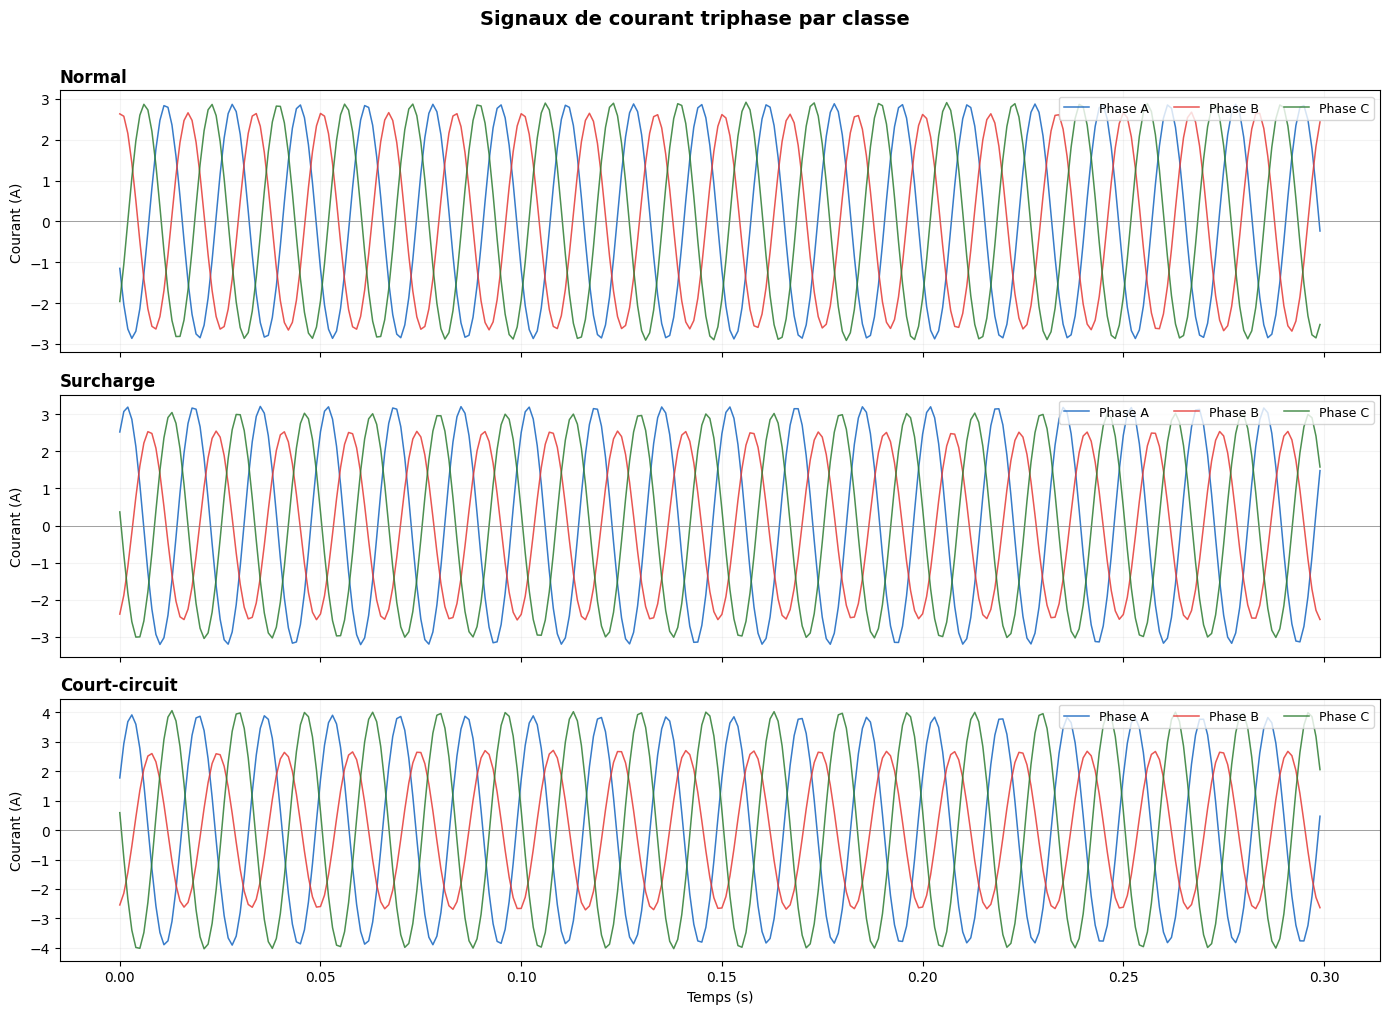

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
colors = ['#1565C0', '#E53935', '#2E7D32']
t = np.arange(300) / 1000

for idx, label in enumerate(['Normal', 'Surcharge', 'Court-circuit']):
    ax = axes[idx]
    sample = [s for s in all_signals if s[1] == label][0][0]
    for p in range(3):
        ax.plot(t, sample[:300, p], label=PHASE_NAMES[p],
                color=colors[p], linewidth=1.1, alpha=0.85)
    ax.set_title(f'{label}', fontsize=12, fontweight='bold', loc='left')
    ax.set_ylabel('Courant (A)')
    ax.legend(loc='upper right', fontsize=9, ncol=3)
    ax.grid(True, alpha=0.15)
    ax.axhline(y=0, color='gray', linewidth=0.5)

axes[-1].set_xlabel('Temps (s)')
plt.suptitle('Signaux de courant triphase par classe',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.2 Distribution des amplitudes par phase

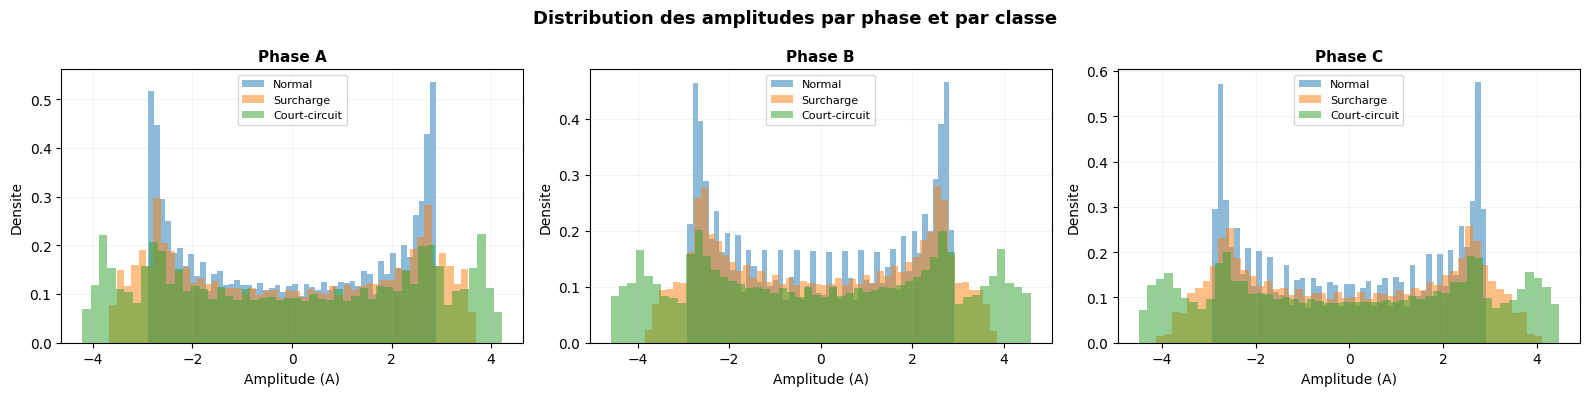

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for p in range(3):
    ax = axes[p]
    for label in ['Normal', 'Surcharge', 'Court-circuit']:
        data = np.concatenate([s[0][:, p] for s in all_signals if s[1] == label])
        ax.hist(data, bins=50, alpha=0.5, label=label, density=True)
    ax.set_title(f'{PHASE_NAMES[p]}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Amplitude (A)')
    ax.set_ylabel('Densite')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.15)

plt.suptitle('Distribution des amplitudes par phase et par classe',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 Superposition des signaux par classe

On superpose toutes les repetitions d'une meme classe pour observer
la variabilite intra-classe.

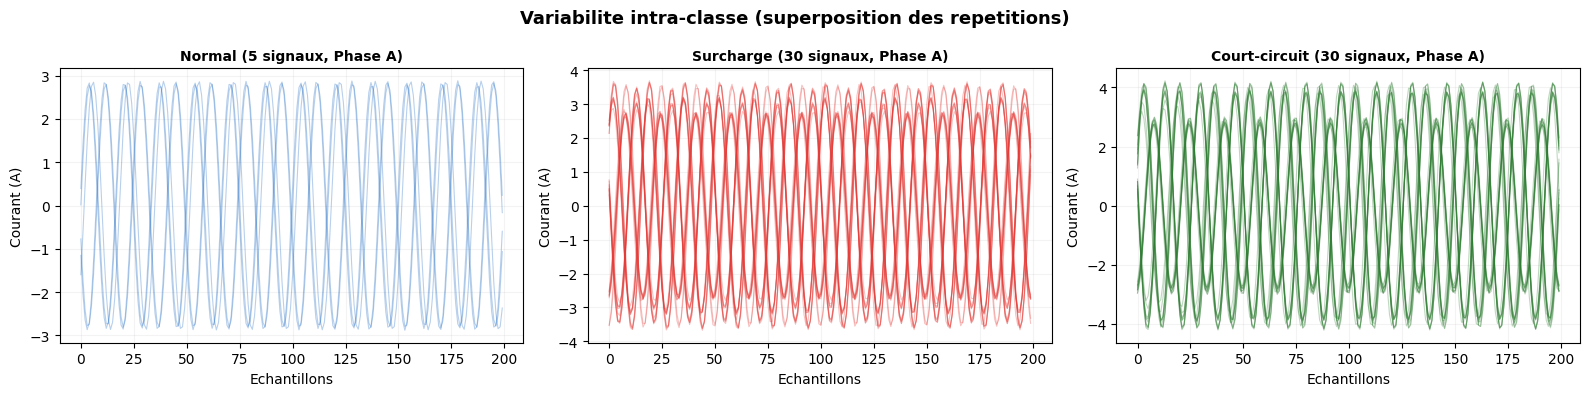

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for idx, label in enumerate(['Normal', 'Surcharge', 'Court-circuit']):
    ax = axes[idx]
    signals_cls = [s[0] for s in all_signals if s[1] == label]
    for sig in signals_cls:
        ax.plot(sig[:200, 0], color=colors[idx], alpha=0.3, linewidth=0.8)
    ax.set_title(f'{label} ({len(signals_cls)} signaux, Phase A)',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Echantillons')
    ax.set_ylabel('Courant (A)')
    ax.grid(True, alpha=0.15)

plt.suptitle('Variabilite intra-classe (superposition des repetitions)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Extraction des caracteristiques

### Strategie

Chaque signal brut (1000 x 3) est transforme en un vecteur de
caracteristiques numeriques. On extrait **15 caracteristiques par phase**,
soit **45 caracteristiques au total**.

**Caracteristiques temporelles (10 par phase)** :
Mean, Std, RMS, Max, Min, Peak-to-Peak, Kurtosis, Skewness, MAD, IQR

**Caracteristiques frequentielles (5 par phase)** :
Energie spectrale, Frequence dominante, Frequence moyenne ponderee,
Dispersion spectrale, Ratio du pic spectral

In [7]:
from scipy.stats import kurtosis, skew
from scipy.fft import fft

def extract_features(signal):
    """
    Extrait 15 caracteristiques par phase d'un signal triphase.
    
    Entree  : signal (n_samples, 3) - signal triphase brut
    Sortie  : vecteur 1D de 45 caracteristiques
    """
    features = []
    n = signal.shape[0]
    
    for phase in range(signal.shape[1]):
        x = signal[:, phase]
        
        # Temporel
        features.append(np.mean(x))
        features.append(np.std(x))
        features.append(np.sqrt(np.mean(x ** 2)))
        features.append(np.max(x))
        features.append(np.min(x))
        features.append(np.max(x) - np.min(x))
        features.append(kurtosis(x))
        features.append(skew(x))
        features.append(np.mean(np.abs(np.diff(x))))
        features.append(np.percentile(x, 75) - np.percentile(x, 25))
        
        # Frequentiel (FFT)
        spectrum = np.abs(fft(x))[:n // 2]
        freqs = np.fft.fftfreq(n, d=1.0 / 1000)[:n // 2]
        features.append(np.sum(spectrum ** 2))
        features.append(freqs[np.argmax(spectrum)])
        features.append(np.sum(freqs * spectrum) / (np.sum(spectrum) + 1e-10))
        features.append(np.std(spectrum))
        features.append(np.max(spectrum) / (np.sum(spectrum) + 1e-10))
    
    return np.array(features)

# Noms des caracteristiques
FEAT_NAMES_PER_PHASE = [
    'Mean', 'Std', 'RMS', 'Max', 'Min', 'PeakToPeak',
    'Kurtosis', 'Skewness', 'MAD', 'IQR',
    'SpectralEnergy', 'DominantFreq', 'MeanFreq', 'SpectralStd', 'SpectralPeakRatio'
]

feature_names = []
for phase in ['PhaseA', 'PhaseB', 'PhaseC']:
    for feat in FEAT_NAMES_PER_PHASE:
        feature_names.append(f'{phase}_{feat}')

print("Extraction des caracteristiques...")
X = np.array([extract_features(s[0]) for s in all_signals])
y = np.array([LABEL_TO_INT[s[1]] for s in all_signals])

print(f"  X : {X.shape}  ({X.shape[1]} caracteristiques par echantillon)")
print(f"  y : {y.shape}  (classes : {np.bincount(y)})")

Extraction des caracteristiques...
  X : (65, 45)  (45 caracteristiques par echantillon)
  y : (65,)  (classes : [ 5 30 30])


### Apercu de la matrice de caracteristiques

In [8]:
feat_df = pd.DataFrame(X, columns=feature_names)
feat_df['Classe'] = [list(LABEL_TO_INT.keys())[v] for v in y]
print(feat_df[feature_names[:10]].describe().round(4).to_string())

       PhaseA_Mean  PhaseA_Std  PhaseA_RMS  PhaseA_Max  PhaseA_Min  PhaseA_PeakToPeak  PhaseA_Kurtosis  PhaseA_Skewness  PhaseA_MAD  PhaseA_IQR
count      65.0000     65.0000     65.0000     65.0000     65.0000            65.0000          65.0000          65.0000     65.0000     65.0000
mean       -0.0000      2.3515      2.3515      3.3777     -3.3749             6.7526          -1.4980          -0.0000      0.7932      4.6828
std         0.0010      0.3462      0.3462      0.5117      0.5098             1.0214           0.0106           0.0005      0.1163      0.6786
min        -0.0048      1.8970      1.8970      2.7049     -4.2133             5.4096          -1.5003          -0.0015      0.6406      3.7690
25%        -0.0004      2.0088      2.0088      2.8800     -3.8806             5.7592          -1.4999          -0.0004      0.6777      4.0416
50%         0.0001      2.2617      2.2617      3.2307     -3.2337             6.4644          -1.4997           0.0001      0.7622     

### Matrice de correlation

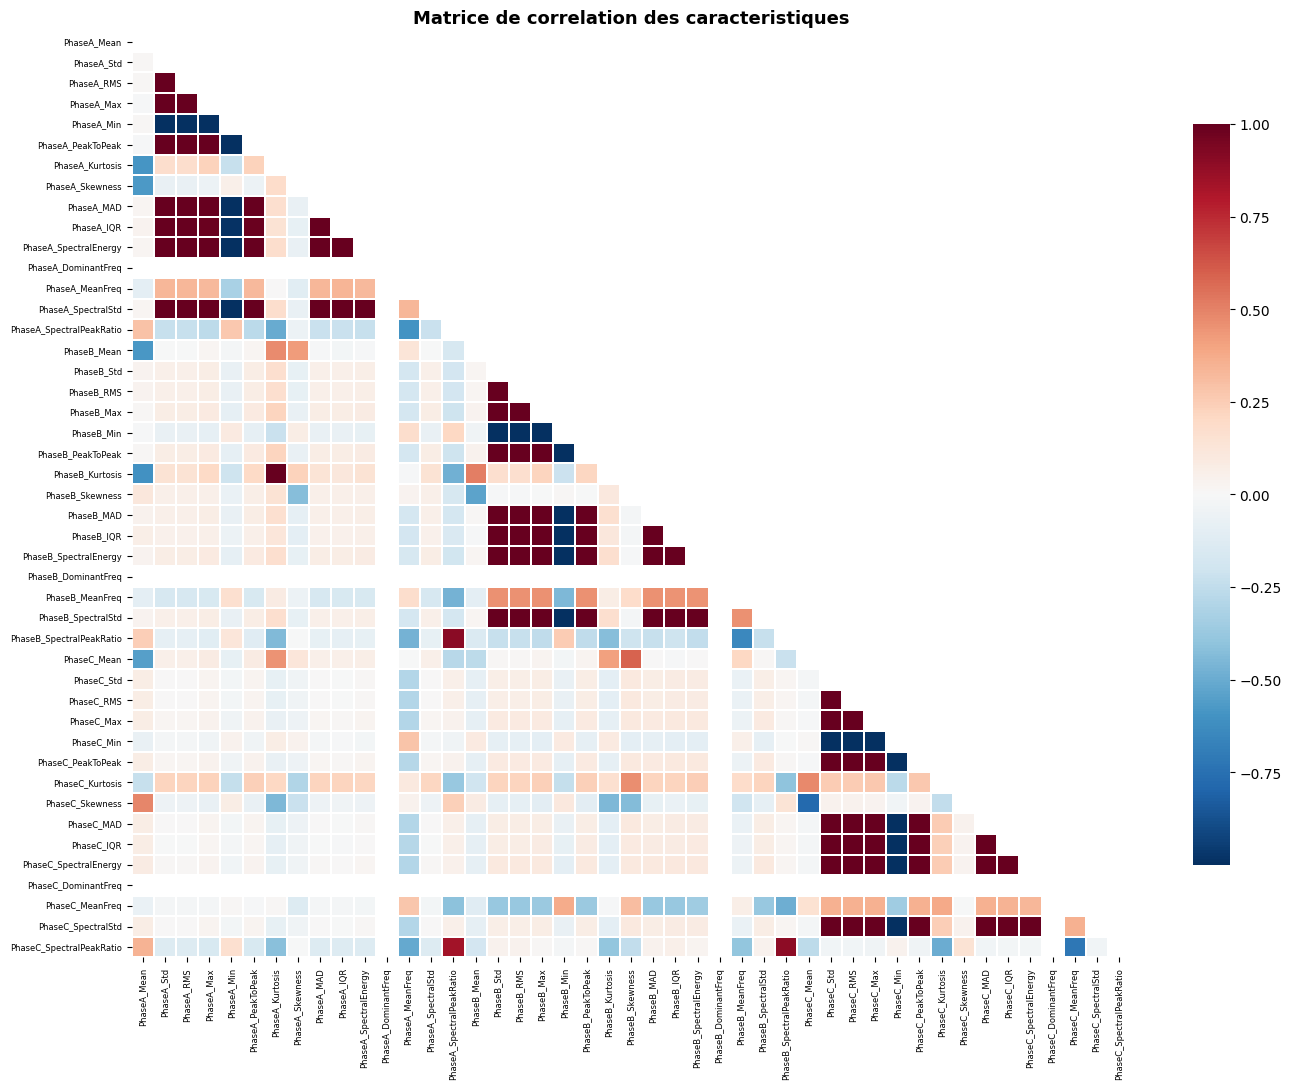

In [9]:
fig, ax = plt.subplots(figsize=(14, 11))
corr = feat_df[feature_names].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, ax=ax,
            linewidths=0.3, cbar_kws={'shrink': 0.8})
ax.set_title('Matrice de correlation des caracteristiques', fontsize=13, fontweight='bold')
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.show()

---
## 6. Preparation des donnees

Partitionnement 80/20 stratifie et normalisation StandardScaler.

In [10]:
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Entrainement : {X_train_scaled.shape[0]} echantillons")
print(f"Test          : {X_test_scaled.shape[0]} echantillons")
print(f"\nDistribution :")
for i, cls in enumerate(LABEL_TO_INT.keys()):
    print(f"  {cls:15s} : train={np.sum(y_train==i)}, test={np.sum(y_test==i)}")

Entrainement : 52 echantillons
Test          : 13 echantillons

Distribution :
  Normal          : train=4, test=1
  Surcharge       : train=24, test=6
  Court-circuit   : train=24, test=6


---
## 7. Entrainement des modeles

Huit classificateurs sont entraines avec optimisation par GridSearchCV
(validation croisee stratifiee a 5 plis).

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier,
                               HistGradientBoostingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score)
import xgboost as xgb
import time

CLASS_NAMES = ['Normal', 'Surcharge', 'Court-circuit']

models_config = {
    'Decision Tree': {
        'estimator': DecisionTreeClassifier(random_state=42),
        'params': {'max_depth': [3, 5, 7, 10], 'min_samples_split': [2, 5, 10],
                   'min_samples_leaf': [1, 2, 4]},
        'esp32': True
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(n_estimators=10, random_state=42),
        'params': {'max_depth': [5, 7, 10], 'min_samples_split': [2, 5],
                   'min_samples_leaf': [1, 2]},
        'esp32': True
    },
    'KNN': {
        'estimator': KNeighborsClassifier(),
        'params': {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance'],
                   'metric': ['euclidean', 'manhattan']},
        'esp32': False
    },
    'SVM Lineaire': {
        'estimator': LinearSVC(random_state=42, max_iter=5000, dual=False),
        'params': {'C': [0.01, 0.1, 1, 10]},
        'esp32': True
    },
    'Regression Logistique': {
        'estimator': LogisticRegression(random_state=42, max_iter=2000),
        'params': {'C': [0.01, 0.1, 1, 10]},
        'esp32': True
    },
    'Perceptron Multicouche': {
        'estimator': MLPClassifier(random_state=42, max_iter=1000, early_stopping=True),
        'params': {'hidden_layer_sizes': [(10,), (20,), (15, 10)],
                   'activation': ['relu', 'tanh'], 'alpha': [0.001, 0.01]},
        'esp32': True
    },
    'HistGradientBoosting': {
        'estimator': HistGradientBoostingClassifier(random_state=42, max_iter=100),
        'params': {'max_depth': [3, 5, 7], 'learning_rate': [0.05, 0.1, 0.2],
                   'min_samples_leaf': [5, 10, 20]},
        'esp32': True
    },
    'XGBoost': {
        'estimator': xgb.XGBClassifier(random_state=42, n_estimators=50,
                                        use_label_encoder=False,
                                        eval_metric='mlogloss', verbosity=0),
        'params': {'max_depth': [3, 5, 7], 'learning_rate': [0.05, 0.1, 0.2],
                   'subsample': [0.8, 1.0]},
        'esp32': True
    },
}

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, cfg in models_config.items():
    print(f"\n{'=' * 65}")
    print(f" {name}")
    print(f"{'=' * 65}")
    
    t0 = time.time()
    grid = GridSearchCV(cfg['estimator'], cfg['params'], cv=cv,
                        scoring='accuracy', n_jobs=-1, refit=True)
    grid.fit(X_train_scaled, y_train)
    
    y_pred = grid.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_pred)
    cv_acc = grid.best_score_
    f1 = f1_score(y_test, y_pred, average='weighted')
    elapsed = time.time() - t0
    
    results[name] = {
        'model': grid.best_estimator_,
        'test_accuracy': test_acc, 'cv_accuracy': cv_acc,
        'f1_score': f1, 'best_params': grid.best_params_,
        'y_pred': y_pred, 'time': elapsed, 'esp32': cfg['esp32']
    }
    
    print(f"  CV Accuracy   : {cv_acc:.4f}")
    print(f"  Test Accuracy : {test_acc:.4f}")
    print(f"  F1-Score      : {f1:.4f}")
    print(f"  Temps         : {elapsed:.2f} s")
    print(f"  Params        : {grid.best_params_}")
    print(f"\n{classification_report(y_test, y_pred, target_names=CLASS_NAMES)}")


 Decision Tree
  CV Accuracy   : 0.9255
  Test Accuracy : 0.8462
  F1-Score      : 0.8462
  Temps         : 5.91 s
  Params        : {'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}

               precision    recall  f1-score   support

       Normal       0.00      0.00      0.00         1
    Surcharge       0.83      0.83      0.83         6
Court-circuit       1.00      1.00      1.00         6

     accuracy                           0.85        13
    macro avg       0.61      0.61      0.61        13
 weighted avg       0.85      0.85      0.85        13


 Random Forest
  CV Accuracy   : 0.9055
  Test Accuracy : 0.9231
  F1-Score      : 0.8876
  Temps         : 0.28 s
  Params        : {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}

               precision    recall  f1-score   support

       Normal       0.00      0.00      0.00         1
    Surcharge       0.86      1.00      0.92         6
Court-circuit       1.00      1.00      1.00    

---
## 8. Evaluation comparative

In [13]:
comp = pd.DataFrame({
    'Modele': list(results.keys()),
    'CV Accuracy': [r['cv_accuracy'] for r in results.values()],
    'Test Accuracy': [r['test_accuracy'] for r in results.values()],
    'F1-Score': [r['f1_score'] for r in results.values()],
    'Temps (s)': [r['time'] for r in results.values()],
    'ESP32': ['Oui' if r['esp32'] else 'Non' for r in results.values()],
}).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print("=" * 80)
print(" CLASSEMENT DES MODELES")
print("=" * 80)
print(comp.to_string(index=False))

 CLASSEMENT DES MODELES
                Modele  CV Accuracy  Test Accuracy  F1-Score  Temps (s) ESP32
         Random Forest     0.905455       0.923077  0.887574   0.284976   Oui
          SVM Lineaire     0.863636       0.923077  0.887574   0.060001   Oui
  HistGradientBoosting     0.923636       0.923077  0.887574   5.344709   Oui
 Regression Logistique     0.881818       0.923077  0.922539   0.088994   Oui
               XGBoost     0.905455       0.923077  0.887574   1.580770   Oui
         Decision Tree     0.925455       0.846154  0.846154   5.908670   Oui
                   KNN     0.863636       0.769231  0.753846   2.634751   Non
Perceptron Multicouche     0.634545       0.384615  0.398601   0.278338   Oui


### Matrices de confusion

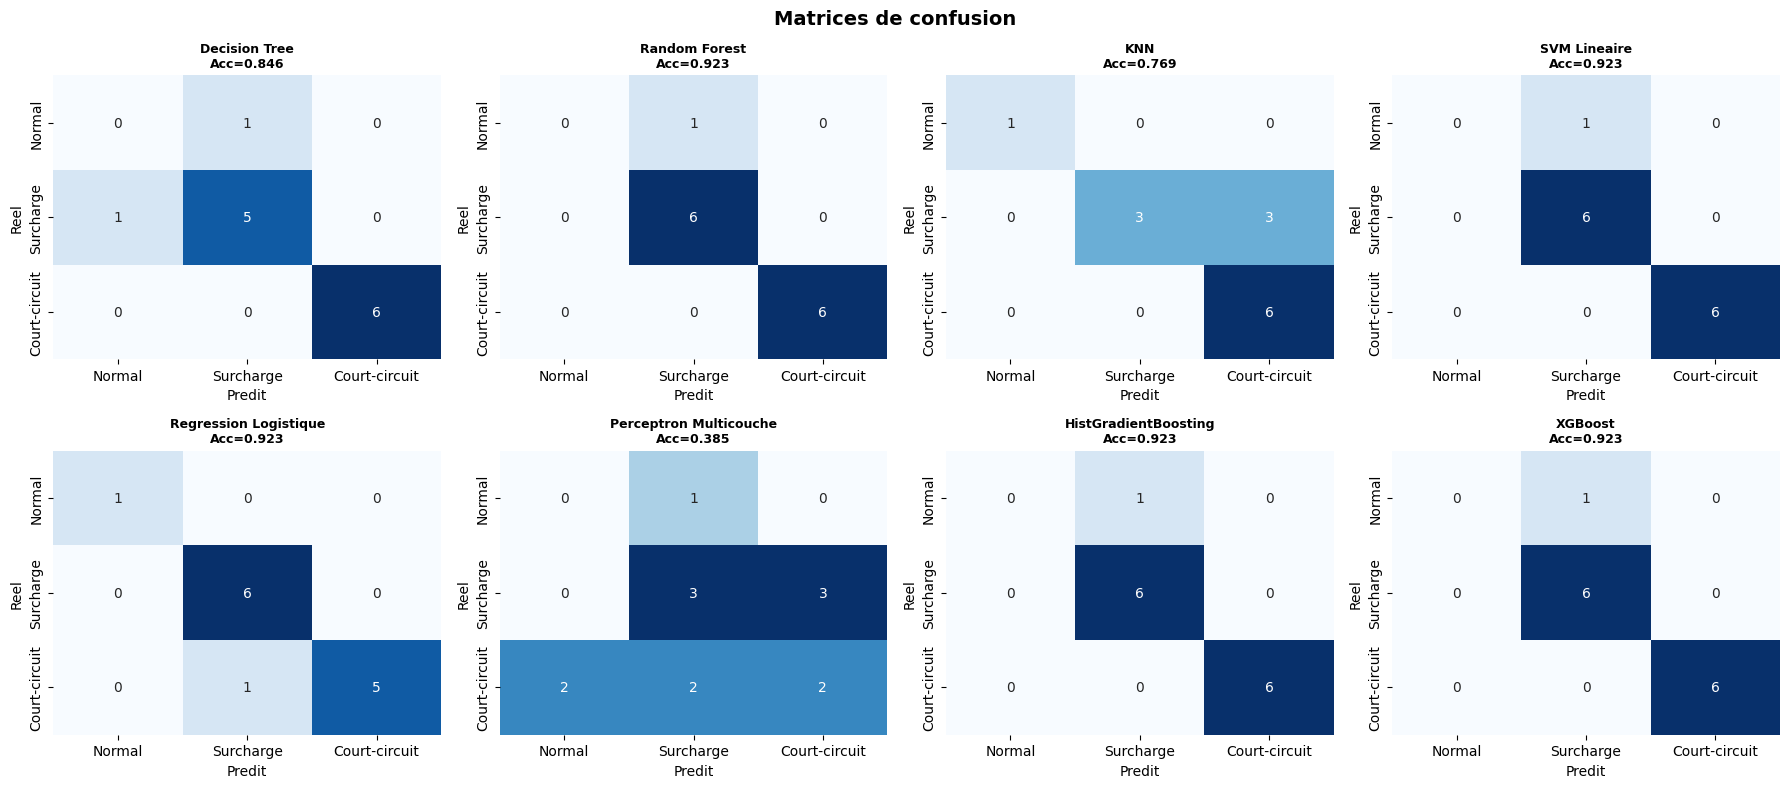

In [14]:
ncols = 4
nrows = (len(results) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 4))
axes_flat = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_flat[idx],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar=False)
    axes_flat[idx].set_title(f'{name}\nAcc={res["test_accuracy"]:.3f}',
                             fontsize=9, fontweight='bold')
    axes_flat[idx].set_ylabel('Reel')
    axes_flat[idx].set_xlabel('Predit')

for idx in range(len(results), len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle('Matrices de confusion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Comparaison graphique

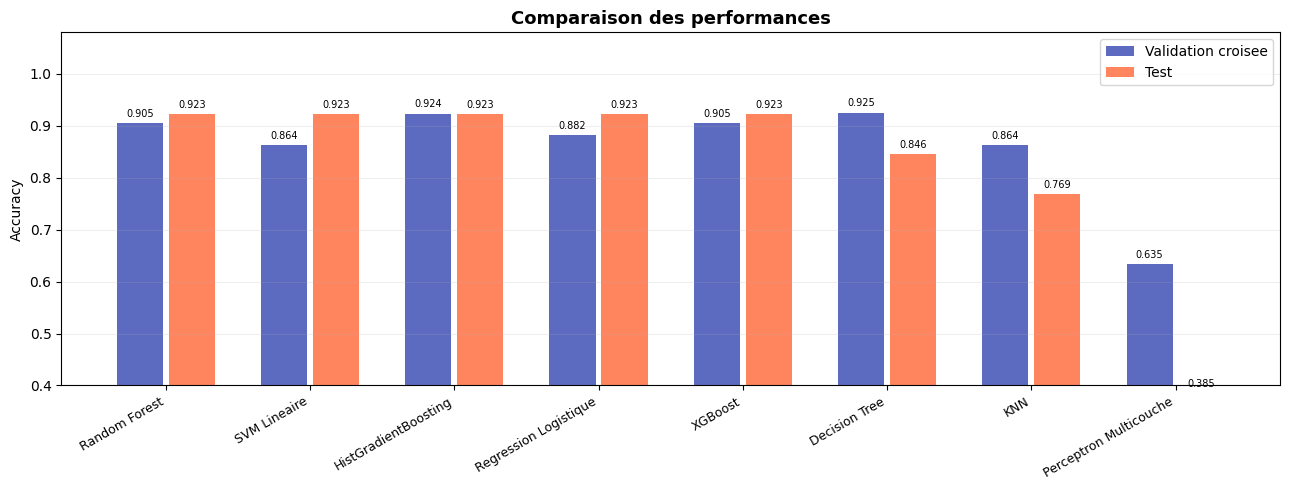

In [15]:
fig, ax = plt.subplots(figsize=(13, 5))
names_list = comp['Modele'].tolist()
x = np.arange(len(names_list))
b1 = ax.bar(x - 0.18, comp['CV Accuracy'], 0.32, label='Validation croisee',
            color='#3F51B5', alpha=0.85)
b2 = ax.bar(x + 0.18, comp['Test Accuracy'], 0.32, label='Test',
            color='#FF7043', alpha=0.85)
ax.set_ylabel('Accuracy')
ax.set_title('Comparaison des performances', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(names_list, rotation=30, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.set_ylim(0.4, 1.08)
ax.grid(axis='y', alpha=0.2)
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.008,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

---
## 9. Importance des caracteristiques

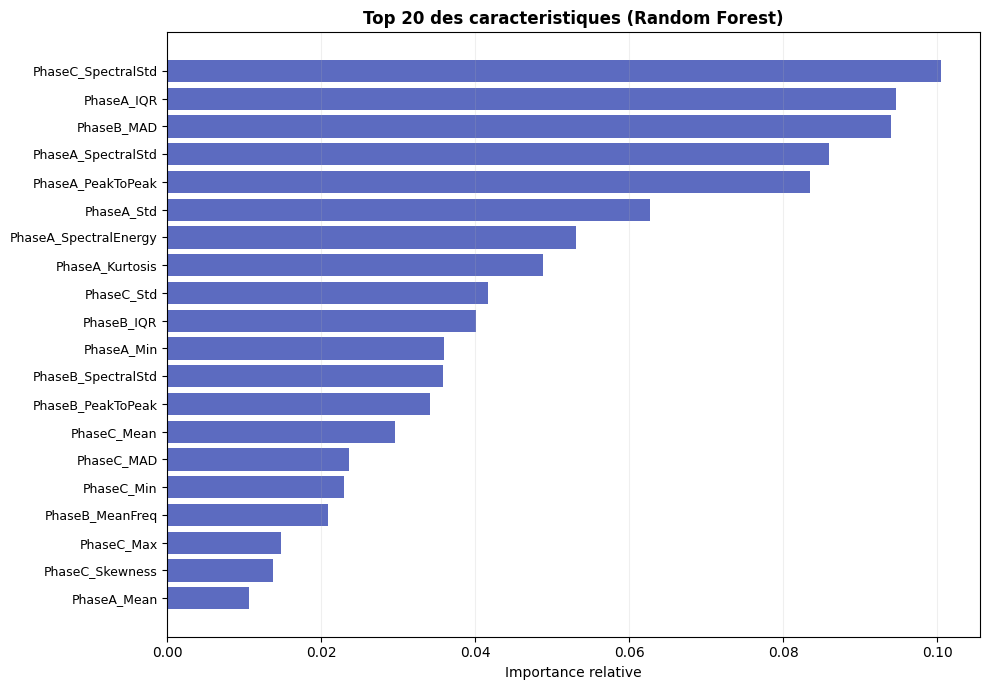


Importance par phase :
  PhaseA : 0.4850 (48.5%)
  PhaseB : 0.2580 (25.8%)
  PhaseC : 0.2570 (25.7%)


In [16]:
tree_models = {k: v for k, v in results.items()
               if hasattr(v['model'], 'feature_importances_')}

if tree_models:
    best_tree = max(tree_models, key=lambda k: tree_models[k]['test_accuracy'])
    importances = tree_models[best_tree]['model'].feature_importances_
    top_idx = np.argsort(importances)[-20:]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(range(len(top_idx)), importances[top_idx], color='#3F51B5', alpha=0.85)
    ax.set_yticks(range(len(top_idx)))
    ax.set_yticklabels([feature_names[i] for i in top_idx], fontsize=9)
    ax.set_xlabel('Importance relative')
    ax.set_title(f'Top 20 des caracteristiques ({best_tree})',
                 fontweight='bold', fontsize=12)
    ax.grid(axis='x', alpha=0.2)
    plt.tight_layout()
    plt.show()

    print("\nImportance par phase :")
    for phase in ['PhaseA', 'PhaseB', 'PhaseC']:
        mask = [i for i, n in enumerate(feature_names) if n.startswith(phase)]
        imp = np.sum(importances[mask])
        print(f"  {phase} : {imp:.4f} ({imp*100:.1f}%)")

---
## 10. Exportation pour ESP32

Le meilleur modele compatible ESP32 est converti en code C natif
avec la bibliotheque `m2cgen`.

In [17]:
import m2cgen as m2c

esp32_models = {k: v for k, v in results.items() if v['esp32']}
best_name = max(esp32_models, key=lambda k: esp32_models[k]['test_accuracy'])
best_model = esp32_models[best_name]['model']

print("=" * 65)
print(" MODELE SELECTIONNE POUR ESP32")
print("=" * 65)
print(f"  Nom            : {best_name}")
print(f"  Test Accuracy  : {esp32_models[best_name]['test_accuracy']:.4f}")
print(f"  F1-Score       : {esp32_models[best_name]['f1_score']:.4f}")
print(f"  Parametres     : {esp32_models[best_name]['best_params']}")

 MODELE SELECTIONNE POUR ESP32
  Nom            : Random Forest
  Test Accuracy  : 0.9231
  F1-Score       : 0.8876
  Parametres     : {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [18]:
# Export du modele en C
c_code = m2c.export_to_c(best_model)

with open('model_esp32.c', 'w') as f:
    f.write(f'/*\n * Modele : {best_name}\n')
    f.write(f' * Accuracy : {esp32_models[best_name]["test_accuracy"]:.4f}\n')
    f.write(f' * Entrees  : {len(feature_names)} caracteristiques\n')
    f.write(f' * Sorties  : 0=Normal, 1=Surcharge, 2=Court-circuit\n */\n\n')
    f.write(c_code)

print(f"\nFichier genere : model_esp32.c ({os.path.getsize('model_esp32.c')/1024:.1f} Ko)")


Fichier genere : model_esp32.c (10.1 Ko)


In [19]:
# Export du scaler
with open('scaler_params.h', 'w') as f:
    f.write('#ifndef SCALER_PARAMS_H\n#define SCALER_PARAMS_H\n\n')
    f.write(f'#define N_FEATURES {len(feature_names)}\n#define N_CLASSES 3\n\n')
    f.write('const float scaler_mean[N_FEATURES] = {\n    ')
    f.write(',\n    '.join(f'{v:.8f}f' for v in scaler.mean_))
    f.write('\n};\n\n')
    f.write('const float scaler_scale[N_FEATURES] = {\n    ')
    f.write(',\n    '.join(f'{v:.8f}f' for v in scaler.scale_))
    f.write('\n};\n\n#endif\n')

print(f"Fichier genere : scaler_params.h")

Fichier genere : scaler_params.h


### Exemple d'integration ESP32

```c
#include "model_esp32.c"
#include "scaler_params.h"

int predict(float features[N_FEATURES]) {
    float scaled[N_FEATURES];
    for (int i = 0; i < N_FEATURES; i++)
        scaled[i] = (features[i] - scaler_mean[i]) / scaler_scale[i];

    double output[N_CLASSES];
    score(scaled, output);

    int best = 0;
    for (int i = 1; i < N_CLASSES; i++)
        if (output[i] > output[best]) best = i;

    return best;  // 0=Normal, 1=Surcharge, 2=Court-circuit
}
```

In [20]:
print("\n" + "=" * 65)
print(" RESUME")
print("=" * 65)
print(f"\n  Modele         : {best_name}")
print(f"  Accuracy       : {esp32_models[best_name]['test_accuracy']:.4f}")
print(f"  Fichiers       : model_esp32.c, scaler_params.h")
print(f"\n  Classement :")
print(comp.to_string(index=False))


 RESUME

  Modele         : Random Forest
  Accuracy       : 0.9231
  Fichiers       : model_esp32.c, scaler_params.h

  Classement :
                Modele  CV Accuracy  Test Accuracy  F1-Score  Temps (s) ESP32
         Random Forest     0.905455       0.923077  0.887574   0.284976   Oui
          SVM Lineaire     0.863636       0.923077  0.887574   0.060001   Oui
  HistGradientBoosting     0.923636       0.923077  0.887574   5.344709   Oui
 Regression Logistique     0.881818       0.923077  0.922539   0.088994   Oui
               XGBoost     0.905455       0.923077  0.887574   1.580770   Oui
         Decision Tree     0.925455       0.846154  0.846154   5.908670   Oui
                   KNN     0.863636       0.769231  0.753846   2.634751   Non
Perceptron Multicouche     0.634545       0.384615  0.398601   0.278338   Oui
